# Silver nanoparticles: relaxation and density of states

This notebook follows the [official ASE Nanoparticle tutorial](https://docs.ase-lib.org/examples_generated/01-gettingstarted/06-nanoparticle.html). It builds isolated silver clusters, relaxes their geometries with the effective-medium theory calculator, evaluates their electronic ground states with GPAW, and compares their densities of states (DOS).

The first model is a 55-atom cuboctahedron and the second contains 640 atoms. Distances and vacuum sizes are in ångström (Å), energies in electronvolts (eV), forces in eV/Å, and DOS values in states/eV.

## Building the Ag₅₅ nanoparticle

`Octahedron('Ag', 5, cutoff=2)` starts from an FCC-consistent octahedral construction and cuts its corners to produce a cuboctahedral Ag₅₅ cluster. The object is isolated: it initially has no finite simulation cell and all periodic-boundary flags are false.

`plot_atoms()` creates a static projection for checking the shape and exposed facets. Its rotation changes only the viewpoint, not the stored coordinates.

In [1]:
from ase.cluster import Octahedron

atoms = Octahedron('Ag', 5, cutoff=2)

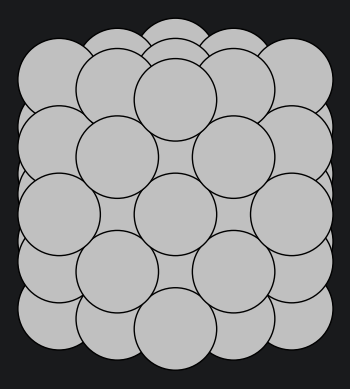

In [2]:
from ase.visualize.plot import plot_atoms
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plot_atoms(atoms, ax, rotation=('-80x,0y,0z'))
ax.set_axis_off()

### Geometry optimization with EMT

EMT supplies inexpensive model energies and forces for the silver cluster. BFGS updates all atomic positions until the largest force satisfies

$$
F_{max} = max_i |F_i| < 0.01 eV/Å.
$$

The displayed run lowers the total EMT energy from 20.334 eV to 18.879 eV and reaches `F_max = 0.0092` eV/Å after 14 optimization steps. `opt.traj` records the relaxation path, and `has_converged` receives the optimizer's Boolean result. The geometry is EMT-relaxed, not DFT-relaxed, which matters when the GPAW DOS is interpreted later.

In [3]:
from ase.calculators.emt import EMT
from ase.optimize import BFGS

atoms.calc = EMT()
opt = BFGS(atoms, trajectory='../files/tutorial_05/opt.traj')
has_converged = opt.run(fmax=0.01)

      Step     Time          Energy          fmax
BFGS:    0 16:20:24       20.334210        0.801013
BFGS:    1 16:20:25       20.147034        0.751003
BFGS:    2 16:20:25       19.301247        0.678888
BFGS:    3 16:20:25       19.196190        0.375474
BFGS:    4 16:20:25       19.155598        0.352885
BFGS:    5 16:20:25       18.907350        0.127899
BFGS:    6 16:20:25       18.893453        0.056286
BFGS:    7 16:20:25       18.891833        0.053418
BFGS:    8 16:20:25       18.886078        0.049818
BFGS:    9 16:20:25       18.882155        0.037683
BFGS:   10 16:20:25       18.880054        0.022328
BFGS:   11 16:20:25       18.879700        0.016541
BFGS:   12 16:20:25       18.879541        0.013518
BFGS:   13 16:20:25       18.879298        0.011513
BFGS:   14 16:20:25       18.879077        0.009199


## GPAW ground-state calculation

Reading `opt.traj` without an explicit index retrieves the final saved optimization frame. The GPAW calculator then performs a single-point electronic-structure calculation on this EMT-relaxed geometry.

`mode='lcao'` uses localized atomic-orbital-like basis functions. The compact `sz(dzp)` basis and the 11-electron Ag PAW setup reduce the computational cost, while `FermiDirac(0.1)` applies 0.1 eV occupation smearing to states near the Fermi level. These are tutorial settings rather than demonstrated convergence choices.

`atoms.center(vacuum=4.0)` creates a finite non-periodic box with 4 Å of vacuum around the cluster, as required by GPAW. `get_potential_energy()` triggers the self-consistent calculation, and `groundstate.gpw` stores the resulting calculator state for later DOS analysis.

In [4]:
from gpaw import GPAW, FermiDirac

from ase.io import read

atoms = read('../files/introductory/tutorial_05/opt.traj')

calc = GPAW(
    mode='lcao',
    basis='sz(dzp)',
    txt='../files/tutorial_05/gpaw.txt',
    occupations=FermiDirac(0.1),
    setups={'Ag': '11'},
)

In [5]:
atoms.calc = calc
atoms.center(vacuum=4.0)
atoms.get_potential_energy()
atoms.calc.write('../files/tutorial_05/groundstate.gpw')

## Density of states

For a finite cluster, the electronic spectrum consists of discrete Kohn–Sham levels. `DOS` represents each level with a Gaussian and sums the contributions:

$$
D(E) = sum_n g_{sigma}(E - epsilon_n).
$$

Here, `npts=800` samples the energy axis at 800 points and `width=0.1` uses 0.1 eV Gaussian broadening. This DOS broadening controls the visible peak resolution and is distinct from the 0.1 eV Fermi–Dirac occupation smearing used in the ground-state calculation. `get_dos()` returns the total DOS rather than an orbital- or atom-projected DOS.

> **Energy-reference note:** `DOS.get_energies()` already reports energies relative to the Fermi level, so `E - E_F = 0` is the Fermi position on this axis. The plotting cell instead draws its vertical line at the absolute value returned by `calc.get_fermi_level()`. To make the line consistent with the current x-axis, draw it at `0.0`; the stored source and output are preserved here.

In [6]:
from ase.dft.dos import DOS

calc = GPAW('../files/introductory/tutorial_05/groundstate.gpw')
dos = DOS(calc, npts=800, width=0.1)
energies = dos.get_energies()
weights = dos.get_dos()
efermi = calc.get_fermi_level()

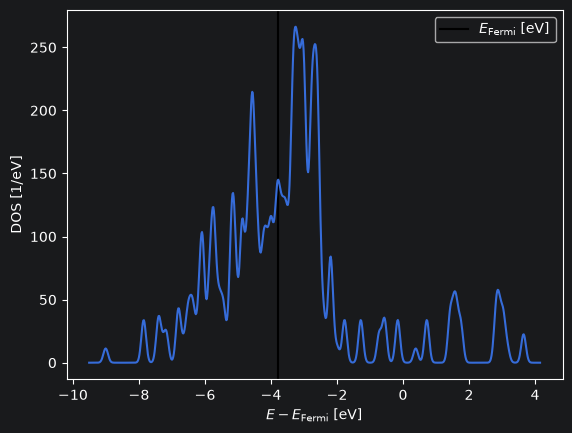

In [7]:
fig, ax = plt.subplots()
ax.axvline(efermi, color='k', label=r'$E_{\mathrm{Fermi}}$ [eV]')
ax.plot(energies, weights)
ax.set_xlabel(r'$E - E_{\mathrm{Fermi}}$ [eV]')
ax.set_ylabel('DOS [1/eV]')
ax.legend()
plt.show()

## Scaling up to an Ag₆₄₀ nanoparticle

`Octahedron('Ag', 10, cutoff=2)` contains 640 atoms and spans a much larger physical diameter than Ag₅₅. Because the edge-length parameter increases while `cutoff` remains fixed, this model also changes the relative truncation and facet proportions; it is therefore not a perfectly shape-preserving size series.

The same visualization, EMT relaxation threshold, GPAW setup, vacuum size, DOS sampling, and Gaussian width are reused to make the two workflows as comparable as the present models allow. The electronic calculation is nevertheless far more expensive because the larger cluster contains many more electrons and basis functions.

In [8]:
atoms_larger = Octahedron('Ag', 10, cutoff=2)

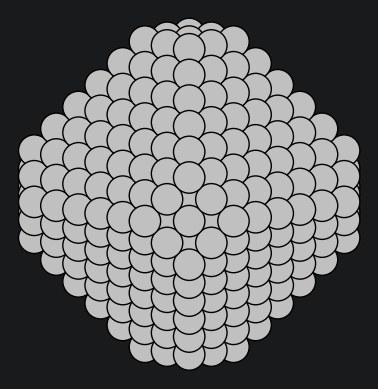

In [9]:
fig, ax = plt.subplots()
plot_atoms(atoms_larger, ax, rotation=('-80x,0y,0z'))
ax.set_axis_off()

### Relaxing the larger cluster

The EMT calculator must be attached to the same `atoms_larger` object passed to BFGS; attaching it to `atoms` would leave the optimized object without forces. With the correct attachment, the stored run reaches `F_max = 0.0099` eV/Å after 38 optimization steps and writes `opt_larger.traj`.

In [10]:
atoms_larger.calc = EMT()
opt = BFGS(atoms_larger, trajectory='../files/tutorial_05/opt_larger.traj')
has_converged = opt.run(fmax=0.01)

      Step     Time          Energy          fmax
BFGS:    0 16:20:42       97.263689        0.605447
BFGS:    1 16:20:42       96.830309        0.566477
BFGS:    2 16:20:43       94.634217        0.438892
BFGS:    3 16:20:43       94.461962        0.287262
BFGS:    4 16:20:44       94.339117        0.235285
BFGS:    5 16:20:44       93.633389        0.265395
BFGS:    6 16:20:45       93.440246        0.357429
BFGS:    7 16:20:45       93.295274        0.355035
BFGS:    8 16:20:46       93.208185        0.299829
BFGS:    9 16:20:46       92.986842        0.120234
BFGS:   10 16:20:47       92.796940        0.148640
BFGS:   11 16:20:47       92.672466        0.215913
BFGS:   12 16:20:48       92.598854        0.227622
BFGS:   13 16:20:48       92.506178        0.183387
BFGS:   14 16:20:49       92.380767        0.102520
BFGS:   15 16:20:49       92.265627        0.094185
BFGS:   16 16:20:50       92.203523        0.081282
BFGS:   17 16:20:50       92.174957        0.071642
BFGS:   18 16:

### Repeating the ground-state and DOS workflow

The final Ag₆₄₀ trajectory frame is loaded into `atoms`, assigned a fresh GPAW calculator, centered in its own 4 Å vacuum box, and written to `groundstate_larger.gpw` after the self-consistent calculation. The DOS is then sampled with the same 800-point grid and 0.1 eV Gaussian width used for Ag₅₅.

Using identical electronic and plotting settings reduces methodological differences, but the plotted quantity remains a total DOS. Its integrated weight and vertical scale grow with the number of electronic states, so raw Ag₅₅ and Ag₆₄₀ peak heights are not directly comparable on a per-atom basis.

In [11]:
atoms = read('../files/introductory/tutorial_05/opt_larger.traj')

calc = GPAW(
    mode='lcao',
    basis='sz(dzp)',
    txt='../files/tutorial_05/gpaw_larger.txt',
    occupations=FermiDirac(0.1),
    setups={'Ag': '11'},
)

In [12]:
atoms.calc = calc
atoms.center(vacuum=4.0)
atoms.get_potential_energy()
atoms.calc.write('../files/tutorial_05/groundstate_larger.gpw')

In [13]:
calc = GPAW('../files/introductory/tutorial_05/groundstate_larger.gpw')
dos = DOS(calc, npts=800, width=0.1)
energies = dos.get_energies()
weights = dos.get_dos()
efermi = calc.get_fermi_level()

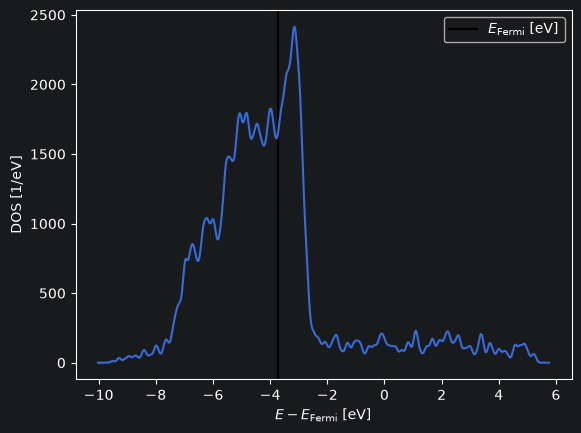

In [14]:
fig, ax = plt.subplots()
ax.axvline(efermi, color='k', label=r'$E_{\mathrm{Fermi}}$ [eV]')
ax.plot(energies, weights)
ax.set_xlabel(r'$E - E_{\mathrm{Fermi}}$ [eV]')
ax.set_ylabel('DOS [1/eV]')
ax.legend()
plt.show()

## How the nanoparticle model affects the DOS

A finite, non-periodic nanoparticle has discrete electronic levels rather than the continuous bands of an infinite crystal. After Gaussian broadening, Ag₅₅ therefore retains separated peaks and gaps, especially around the Fermi level. Ag₆₄₀ has many more closely spaced levels, so its peaks overlap and the DOS becomes smoother and more bulk-like. It is still a finite-cluster spectrum, not a fully continuous bulk DOS.

The larger total DOS also has a much greater vertical magnitude simply because Ag₆₄₀ contains about 11.6 times as many atoms and electronic states as Ag₅₅. To compare spectral shape rather than system size, divide each DOS by its atom count or normalize its integral over a common energy window.

Size is not the only structural effect. Ag₅₅ has a larger fraction of low-coordination corner, edge, and surface atoms, whose altered orbital overlap can shift, split, or narrow DOS features relative to bulk-like interior atoms. The `length` and `cutoff` choices determine facet areas and site populations, while EMT relaxation determines bond lengths and any surface reconstruction. Because the GPAW calculations are single points on EMT geometries, these structural assumptions are inherited by the DOS. The Ag₆₄₀ model also uses a different relative truncation, so the comparison mixes size and shape effects.

The broad occupied feature several eV below the Fermi level is expected to have strong Ag `d` character, while the more widely separated states near the Fermi level are expected to contain stronger `s` character. This assignment is a physical interpretation, not something demonstrated by the total DOS; orbital-projected and atom-resolved DOS calculations are needed to test it. Comparing center, facet, edge, and corner atoms would separate bulk-like and surface contributions.

The numerical model also changes what is visible. The LCAO basis and PAW setup affect the level positions, the 0.1 eV DOS width can merge nearby levels, and Fermi–Dirac smearing affects occupations near the Fermi level. In addition, the 11-electron setup gives Ag₅₅ an odd total valence-electron count, but the calculation does not explicitly request spin polarization; a spin-polarized test could therefore change the near-Fermi DOS.

### Takeaways and possible extensions

A controlled size study should keep the relative shape, calculator settings, energy reference, broadening, and normalization consistent. Useful extensions include a shape-preserving sequence of cluster sizes, DOS per atom, `s`/`p`/`d`-projected DOS, site-resolved DOS, spin-polarized calculations, DFT relaxation, and comparison with bulk FCC Ag using converged basis, vacuum, PAW setup, and smearing choices. See the [GPAW DOS documentation](https://gpaw.readthedocs.io/tutorialsexercises/electronic/dos/dos.html) for projected-DOS methods.